In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [31]:
df=pd.read_csv('C:/a/ai/data/malware.csv')
df

,Unnamed: 0,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
0,65416,VirusShare_3ede9b62781398a2e39a0f6af9356a54,3ede9b62781398a2e39a0f6af9356a54,332,224,258,10,0,117760,392192,...,5,3.425849,2.458492,4.035538,3146.400000,48,9640,72,15,0
1,23220,fxsocm.dll,9a0959a682d8eba06d0bd181c49ee2a8,332,224,8462,7,10,112640,29696,...,8,3.911994,2.669737,5.335373,1222.750000,164,4889,72,16,1
2,118017,VirusShare_abe7101746242c922a539ba461db4e38,abe7101746242c922a539ba461db4e38,332,224,258,10,0,119808,385024,...,6,3.776760,2.458492,5.317552,2740.166667,48,9640,72,15,0
3,69842,VirusShare_64a1247fc96d5bc2994ef89ca09adee8,64a1247fc96d5bc2994ef89ca09adee8,332,224,258,10,0,120320,385024,...,6,3.756068,2.458492,5.317552,2739.500000,48,9640,72,15,0
4,22165,asferror.dll,ebc23440aa9cc4f08241d35147c1d5b5,332,224,8462,7,10,0,7168,...,2,3.488703,3.471506,3.505901,3050.000000,888,5212,0,16,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,130617,VirusShare_8e8aff35dc7a3719be3834ba1ab76a37,8e8aff35dc7a3719be3834ba1ab76a37,332,224,258,9,0,102400,599040,...,7,4.143516,2.623078,5.916356,81061.000000,62,535040,72,0,0
9996,42632,VirusShare_c3cff0c2f56839d4b54b9cc33f8ea9ad,c3cff0c2f56839d4b54b9cc33f8ea9ad,332,224,258,10,0,118784,383488,...,16,6.378131,2.458492,7.992688,20821.937500,48,33945,72,14,0
9997,82334,VirusShare_223104e64eb3cfdae9dc7a068a2eb8f4,223104e64eb3cfdae9dc7a068a2eb8f4,332,224,258,10,0,120320,385024,...,6,3.756068,2.458492,5.317552,2739.500000,48,9640,72,15,0
9998,89459,VirusShare_df1a1468dcdf897a84bc9d8d92be449f,df1a1468dcdf897a84bc9d8d92be449f,332,224,258,10,0,118784,381952,...,24,6.900106,2.458492,7.990487,13895.833333,48,22648,72,14,0


In [32]:
df.isna().sum()

Unnamed: 0                     0
Name                           0
md5                            0
Machine                        0
SizeOfOptionalHeader           0
Characteristics                0
MajorLinkerVersion             0
MinorLinkerVersion             0
SizeOfCode                     0
SizeOfInitializedData          0
SizeOfUninitializedData        0
AddressOfEntryPoint            0
BaseOfCode                     0
BaseOfData                     0
ImageBase                      0
SectionAlignment               0
FileAlignment                  0
MajorOperatingSystemVersion    0
MinorOperatingSystemVersion    0
MajorImageVersion              0
MinorImageVersion              0
MajorSubsystemVersion          0
MinorSubsystemVersion          0
SizeOfImage                    0
SizeOfHeaders                  0
CheckSum                       0
Subsystem                      0
DllCharacteristics             0
SizeOfStackReserve             0
SizeOfStackCommit              0
SizeOfHeap

In [33]:
features=df.drop(['legitimate','Unnamed: 0','Name','md5'], axis=1)
label=df['legitimate']

X_train, X_test, y_train, y_test=train_test_split(features, label, test_size=0.2, random_state=1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 54) (2000, 54) (8000,) (2000,)


In [34]:
sc=StandardScaler()
X_train_sc=sc.fit_transform(X_train)
X_test_sc=sc.transform(X_test)

In [35]:
X_train_tensor=torch.from_numpy(X_train_sc).float()
X_test_tensor=torch.from_numpy(X_test_sc).float()
print(X_train_tensor.shape, X_test_tensor.shape)

torch.Size([8000, 54]) torch.Size([2000, 54])


In [36]:
y_train_tensor=torch.from_numpy(y_train.values).float().unsqueeze(1)
y_test_tensor=torch.from_numpy(y_test.values).float().unsqueeze(1)
print(y_train_tensor.shape, y_test_tensor.shape)

torch.Size([8000, 1]) torch.Size([2000, 1])


In [37]:
class MalwareModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear=nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.LeakyReLU(0.1),
            nn.Linear(200,100),
            nn.LeakyReLU(0.1),
            nn.Linear(100,20),
            nn.LeakyReLU(0.1),
            nn.Linear(20,5),
            nn.LeakyReLU(0.1),
            nn.Linear(5, output_dim),
            nn.Sigmoid()
        )


    def forward(self, x):
        y=self.linear(x)
        return y

In [38]:
input_dim=X_train_tensor.shape[1]
output_dim=y_train_tensor.shape[1]

In [39]:
model=MalwareModel(input_dim, output_dim)

In [40]:
bceloss=nn.BCELoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.001)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [41]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(X_train_tensor, y_train_tensor)
train_loader=DataLoader(train_dataset, batch_size=250, shuffle=True)


loss1=[]
num_epochs=100

for epoch in range(num_epochs):
    for x,y in train_loader:
        y_pred=model(x)
        loss=bceloss(y_pred,y)
        loss1.append(loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    
    print(sum(loss1)/len(loss1))
    

tensor(0.7142, grad_fn=<DivBackward0>)
tensor(0.4505, grad_fn=<DivBackward0>)
tensor(0.3195, grad_fn=<DivBackward0>)
tensor(0.2517, grad_fn=<DivBackward0>)
tensor(0.2100, grad_fn=<DivBackward0>)
tensor(0.1817, grad_fn=<DivBackward0>)
tensor(0.1611, grad_fn=<DivBackward0>)
tensor(0.1454, grad_fn=<DivBackward0>)
tensor(0.1330, grad_fn=<DivBackward0>)
tensor(0.1230, grad_fn=<DivBackward0>)
tensor(0.1146, grad_fn=<DivBackward0>)
tensor(0.1076, grad_fn=<DivBackward0>)
tensor(0.1016, grad_fn=<DivBackward0>)
tensor(0.0963, grad_fn=<DivBackward0>)
tensor(0.0917, grad_fn=<DivBackward0>)
tensor(0.0875, grad_fn=<DivBackward0>)
tensor(0.0837, grad_fn=<DivBackward0>)
tensor(0.0804, grad_fn=<DivBackward0>)
tensor(0.0773, grad_fn=<DivBackward0>)
tensor(0.0753, grad_fn=<DivBackward0>)
tensor(0.0733, grad_fn=<DivBackward0>)
tensor(0.0710, grad_fn=<DivBackward0>)
tensor(0.0688, grad_fn=<DivBackward0>)
tensor(0.0678, grad_fn=<DivBackward0>)
tensor(0.0663, grad_fn=<DivBackward0>)
tensor(0.0649, grad_fn=<D

In [42]:
total=0
correct=0

with torch.no_grad():
    for x,y in train_loader:
        outputs=model(x)
        predict=(outputs > 0.5).float()
        total+=y.size(0)
        correct+=(predict==y).sum().item()
        print(y.size(0))
        
accuracy=correct/total
print(sum(loss1)/len(loss1))
print(accuracy)

250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
250
tensor(0.0334, grad_fn=<DivBackward0>)
0.9985


In [53]:
test_dataset=TensorDataset(X_test_tensor, y_test_tensor)
test_loader=DataLoader(test_dataset, batch_size=250, shuffle=False)

y_pred=[]

model.eval()
with torch.no_grad():
    for x,_ in test_loader:
        y_test_pred=model(x)
        y_test_pred_sigmoid=torch.round(y_test_pred)
        y_pred.extend(y_test_pred_sigmoid)


y_pred_tensor=torch.tensor(y_pred)
print(y_pred)

[tensor([1.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tenso

In [57]:
accuracy = (y_pred_tensor == y_test_tensor.view_as(y_pred_tensor)).float().mean()
print(accuracy.item())

0.9819999933242798


In [56]:
y_numpy_test=y_test_tensor.numpy()
y_numpy_pred=y_pred_tensor.numpy()
print(y_numpy_test.shape,y_numpy_pred.shape)

(2000, 1) (2000,)


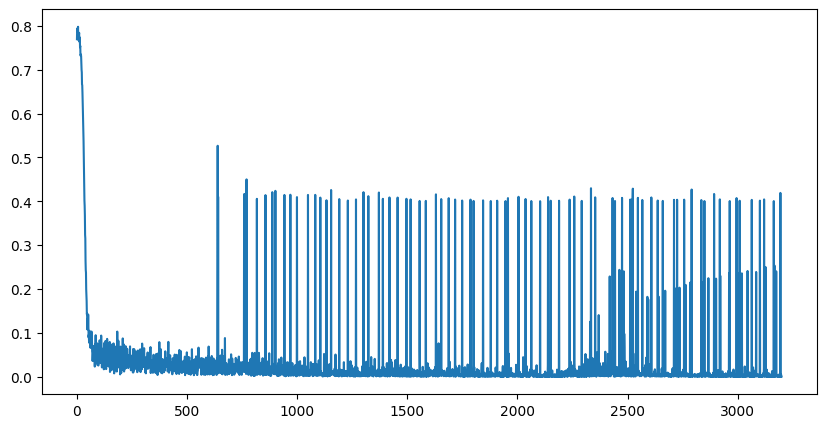

In [48]:
plt.figure(figsize=(10, 5))
plt.plot([l.item() if torch.is_tensor(l) else l for l in loss1])

plt.show()